In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier


from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

import kagglehub

import os



In [29]:
# Download latest version
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

print("Path to dataset files:", path)
df = pd.read_csv(os.path.join(path, "heart.csv"))

Path to dataset files: C:\Users\antan\.cache\kagglehub\datasets\fedesoriano\heart-failure-prediction\versions\1


# Perform data exploration and visualizations

In [30]:
#Gather basic info and column types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [31]:
#View top rows
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [32]:
#check for duplicates
df.duplicated().sum()

0

In [33]:
#View statistics for numerical data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


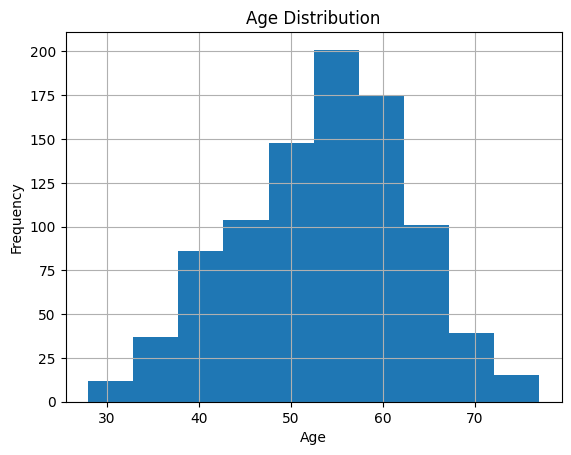

In [34]:
#Create histogram of age column

df["Age"].hist()

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()

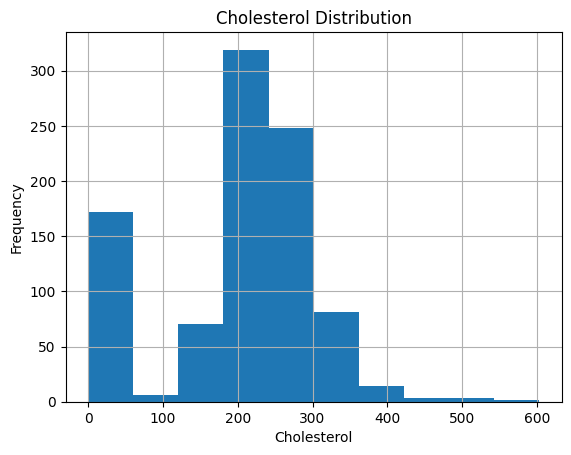

In [35]:
#Create histogram of Cholesterol column

df["Cholesterol"].hist()

plt.xlabel("Cholesterol")
plt.ylabel("Frequency")
plt.title("Cholesterol Distribution")
plt.show()

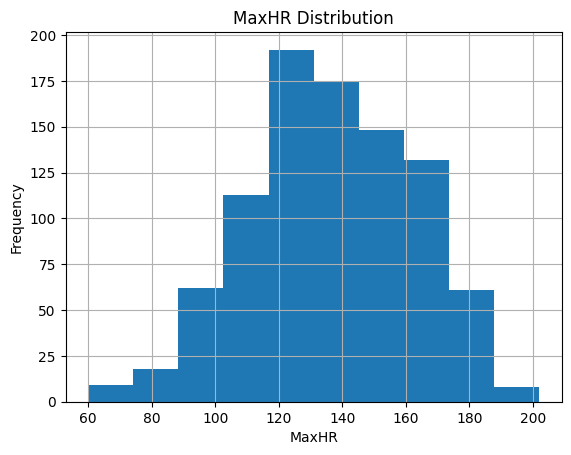

In [36]:
#Create histogram of MaxHR column

df["MaxHR"].hist()

plt.xlabel("MaxHR")
plt.ylabel("Frequency")
plt.title("MaxHR Distribution")
plt.show()

In [37]:
print(df["Sex"].value_counts())
print("################")
print(df["ChestPainType"].value_counts())
print("################")
print(df["RestingECG"].value_counts())
print("################")
print(df["ExerciseAngina"].value_counts())
print("################")
print(df["ST_Slope"].value_counts())

Sex
M    725
F    193
Name: count, dtype: int64
################
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64
################
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64
################
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64
################
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64


# Data preparation for the model training

In [38]:
#Perform one-hot encoding
df_new = pd.get_dummies(df, drop_first=True)
df_new.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True


In [39]:
#Drop heart disease column, which is the output column
X=df_new.drop("HeartDisease",axis=1)
Y=df_new["HeartDisease"]

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=1,
    stratify=Y
)


In [41]:
""""
    "LogisticRegression": LogisticRegression(),
    "LinearSVC": LinearSVC(),
    "KNN": KNeighborsClassifier(),
    "RandomForest": RandomForestClassifier(random_state=42)
"""

'"\n    "LogisticRegression": LogisticRegression(),\n    "LinearSVC": LinearSVC(),\n    "KNN": KNeighborsClassifier(),\n    "RandomForest": RandomForestClassifier(random_state=42)\n'

# Model Training

### 1. Logistic Regression

In [42]:
Model_LR = LogisticRegression()
Model_LR.fit(X_train, y_train)
y_pred_LR = Model_LR.predict(X_test)

c:\Users\antan\miniconda3\envs\AIHC\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### 2. Linear SVC

In [43]:
Model_SVC = LinearSVC()
Model_SVC.fit(X_train, y_train)
y_pred_SVC = Model_SVC.predict(X_test)

### 3. Random Forest

In [44]:
Model_RF = RandomForestClassifier(random_state=42)
Model_RF.fit(X_train, y_train)
y_pred_RF = Model_RF.predict(X_test)

# Model Inspection

### 1. Logistic Regression

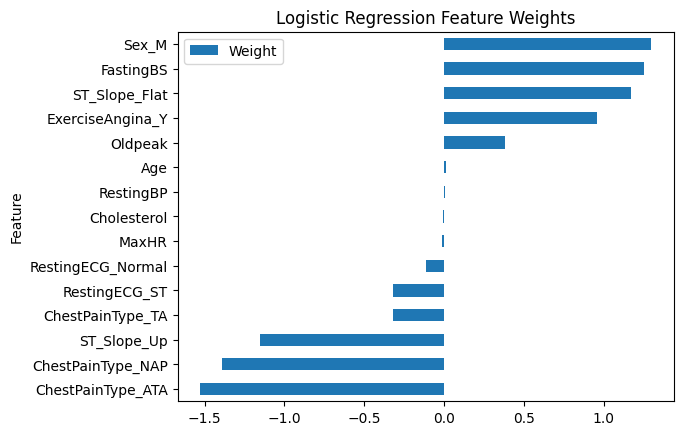

In [45]:
coeffs_lr = pd.DataFrame({
    "Feature": X_train.columns,
    "Weight": Model_LR.coef_[0]
})

coeffs_lr.sort_values(by="Weight", ascending=False)


coeffs_lr.sort_values("Weight").plot.barh(x="Feature", y="Weight")
plt.title("Logistic Regression Feature Weights")
plt.show()

In [46]:
probs = Model_LR.predict_proba(X_test)
probs[:10],y_pred_LR[:10]

(array([[0.77659873, 0.22340127],
        [0.04916908, 0.95083092],
        [0.03203334, 0.96796666],
        [0.28903605, 0.71096395],
        [0.00321838, 0.99678162],
        [0.1029433 , 0.8970567 ],
        [0.19415902, 0.80584098],
        [0.95268596, 0.04731404],
        [0.79902341, 0.20097659],
        [0.89550763, 0.10449237]]),
 array([0, 1, 1, 1, 1, 1, 1, 0, 0, 0], dtype=int64))

### 2. Linear SVC

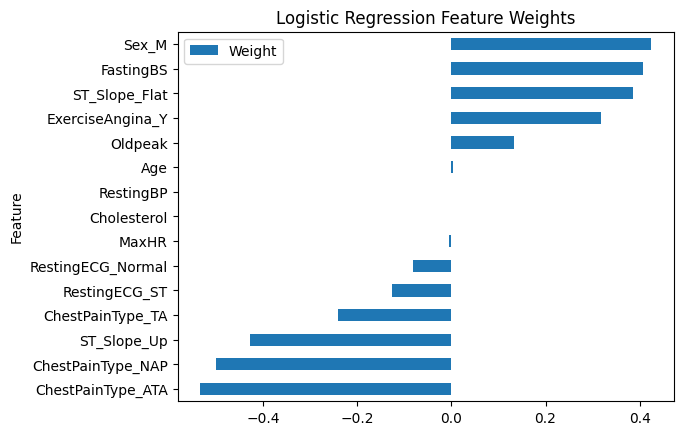

In [47]:
coeffs_svc = pd.DataFrame({
    "Feature": X_train.columns,
    "Weight": Model_SVC.coef_[0]
})

coeffs_svc.sort_values(by="Weight", ascending=False)


coeffs_svc.sort_values("Weight").plot.barh(x="Feature", y="Weight")
plt.title("Logistic Regression Feature Weights")
plt.show()

In [48]:
scores = Model_SVC.decision_function(X_test)
scores[:10], y_pred_SVC[:10]

(array([-0.40842057,  1.01881449,  1.18659184,  0.36648644,  1.95960312,
         0.75810892,  0.4000497 , -1.01715524, -0.42663006, -0.76958367]),
 array([0, 1, 1, 1, 1, 1, 1, 0, 0, 0], dtype=int64))

### 3. Random Forest

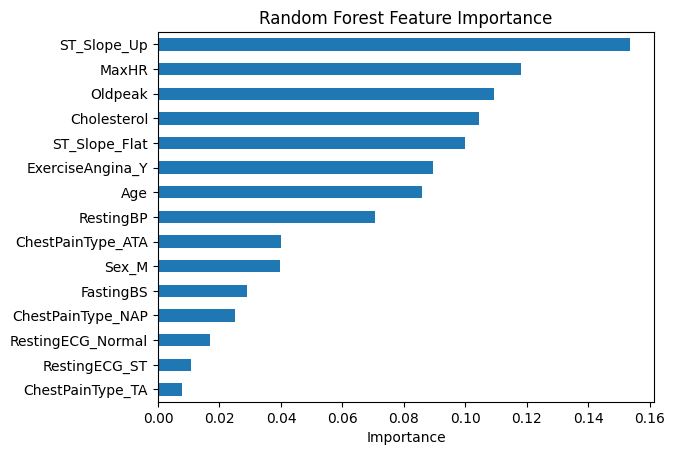

In [49]:
importance = pd.Series(Model_RF.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=True)

importance.plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

In [50]:
tree = Model_RF.estimators_[1]

In [51]:
from sklearn.tree import export_text

tree_rules = export_text(
    tree,
    feature_names=list(X_train.columns),
    max_depth=3
)

print(tree_rules)

|--- ExerciseAngina_Y <= 0.50
|   |--- Cholesterol <= 156.50
|   |   |--- Cholesterol <= 42.50
|   |   |   |--- ST_Slope_Up <= 0.50
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- ST_Slope_Up >  0.50
|   |   |   |   |--- truncated branch of depth 7
|   |   |--- Cholesterol >  42.50
|   |   |   |--- Sex_M <= 0.50
|   |   |   |   |--- class: 0.0
|   |   |   |--- Sex_M >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |--- Cholesterol >  156.50
|   |   |--- RestingECG_Normal <= 0.50
|   |   |   |--- ST_Slope_Up <= 0.50
|   |   |   |   |--- truncated branch of depth 10
|   |   |   |--- ST_Slope_Up >  0.50
|   |   |   |   |--- truncated branch of depth 9
|   |   |--- RestingECG_Normal >  0.50
|   |   |   |--- ST_Slope_Flat <= 0.50
|   |   |   |   |--- truncated branch of depth 8
|   |   |   |--- ST_Slope_Flat >  0.50
|   |   |   |   |--- truncated branch of depth 8
|--- ExerciseAngina_Y >  0.50
|   |--- ST_Slope_Up <= 0.50
|   |   |--- Oldpeak <= 3.10
|   |   | 

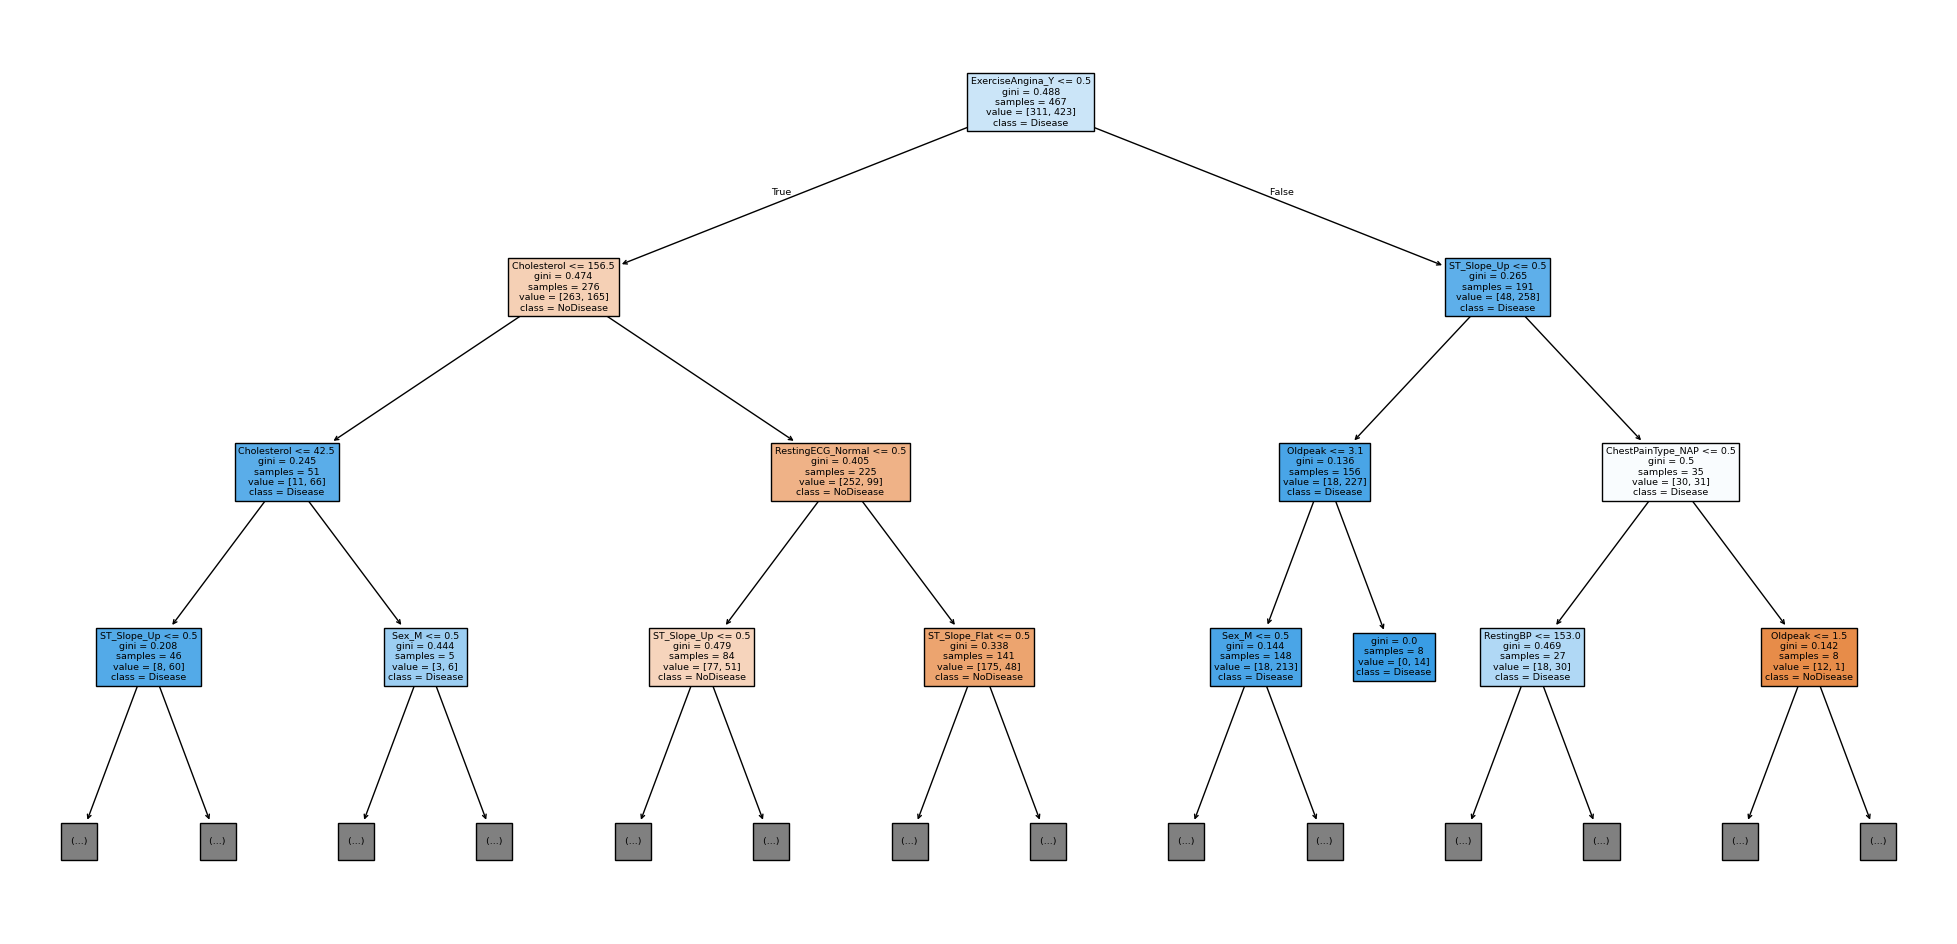

In [52]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(25,12))
plot_tree(
    tree,
    feature_names=X_train.columns,
    class_names=["NoDisease","Disease"],
    filled=True,
    max_depth=3
)
plt.show()

# Model Evaluation

### 1. Logistic Regression

Accuracy: 0.8478260869565217
Precision: 0.8425925925925926
Recall: 0.8921568627450981


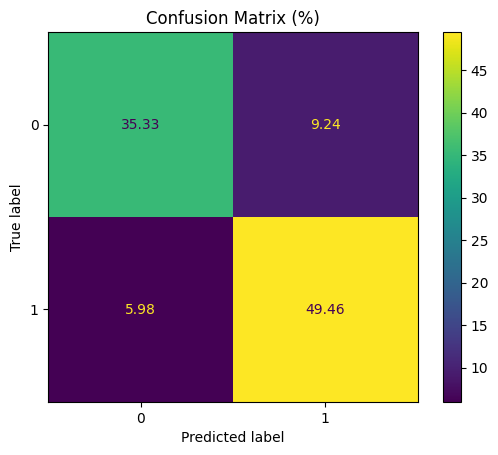

In [53]:
# metrics
print("Accuracy:", accuracy_score(y_test, y_pred_LR))
print("Precision:", precision_score(y_test, y_pred_LR)) # When the model predicts heart disease, it is correct X% of the time. Avoid false alarms.
print("Recall:", recall_score(y_test, y_pred_LR)) #The model detects Χ% of people who truly have heart disease. Out of all patients who actually have heart disease, how many did the model correctly detect?. For a medical screening model, high recall is desirable
 

# confusion matrix
cm_LR = confusion_matrix(y_test, y_pred_LR)

# convert to percentages
cm_percent_LR = cm_LR / cm_LR.sum() * 100

disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent_LR)
disp.plot(values_format=".2f")

plt.title("Confusion Matrix (%)")
plt.show()

### 2. Linear SVC

Accuracy: 0.8586956521739131
Precision: 0.8518518518518519
Recall: 0.9019607843137255


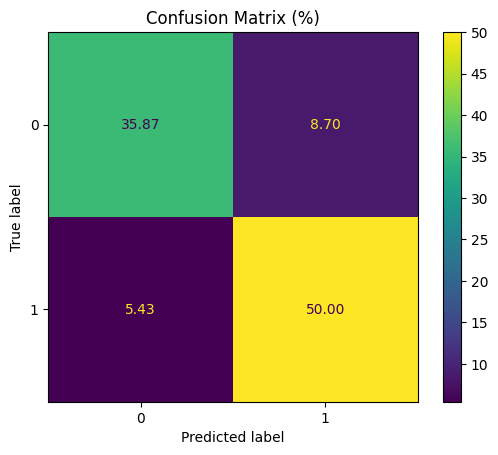

In [54]:
# metrics
print("Accuracy:", accuracy_score(y_test, y_pred_SVC))
print("Precision:", precision_score(y_test, y_pred_SVC)) # When the model predicts heart disease, it is correct X% of the time. Avoid false alarms.
print("Recall:", recall_score(y_test, y_pred_SVC)) #The model detects Χ% of people who truly have heart disease. Out of all patients who actually have heart disease, how many did the model correctly detect?. For a medical screening model, high recall is desirable
 

# confusion matrix
cm_SVC = confusion_matrix(y_test, y_pred_SVC)

# convert to percentages
cm_percent_SVC = cm_SVC / cm_SVC.sum() * 100

disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent_SVC)
disp.plot(values_format=".2f")

plt.title("Confusion Matrix (%)")
plt.show()

### 3. Random Forest

Accuracy: 0.8641304347826086
Precision: 0.8532110091743119
Recall: 0.9117647058823529


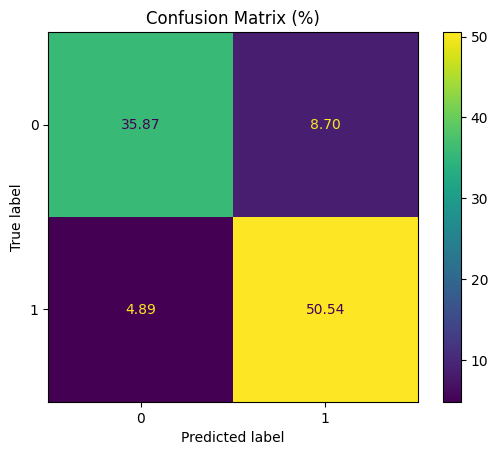

In [55]:
# metrics
print("Accuracy:", accuracy_score(y_test, y_pred_RF))
print("Precision:", precision_score(y_test, y_pred_RF)) # When the model predicts heart disease, it is correct X% of the time. Avoid false alarms.
print("Recall:", recall_score(y_test, y_pred_RF)) #The model detects Χ% of people who truly have heart disease. Out of all patients who actually have heart disease, how many did the model correctly detect?. For a medical screening model, high recall is desirable
 

# confusion matrix
cm_RF = confusion_matrix(y_test, y_pred_RF)

# convert to percentages
cm_percent_RF = cm_RF / cm_SVC.sum() * 100

disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent_RF)
disp.plot(values_format=".2f")

plt.title("Confusion Matrix (%)")
plt.show()

### Combine metrics across all models

In [56]:


results = pd.DataFrame({
    "LR": [
        accuracy_score(y_test, y_pred_LR),
        precision_score(y_test, y_pred_LR),
        recall_score(y_test, y_pred_LR)
    ],
    "LinearSVC": [
        accuracy_score(y_test, y_pred_SVC),
        precision_score(y_test, y_pred_SVC),
        recall_score(y_test, y_pred_SVC)
    ],
    "RF": [
        accuracy_score(y_test, y_pred_RF),
        precision_score(y_test, y_pred_RF),
        recall_score(y_test, y_pred_RF)
    ]
}, index=["Accuracy", "Precision", "Recall"])

results = results.round(3)
print(results)

              LR  LinearSVC     RF
Accuracy   0.848      0.859  0.864
Precision  0.843      0.852  0.853
Recall     0.892      0.902  0.912
